<table align="left">
  <td><a target="_blank" href="https://colab.research.google.com/github/anvasquezre/EAFIT_AA_2026-02/blob/main/notebooks/05_ml_reduccion_dimensionalidad.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a></td>
  <td><a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/anvasquezre/EAFIT_AA_2026-02/blob/main/notebooks/05_ml_reduccion_dimensionalidad.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Abrir en Kaggle"/></a></td>
</table>
<br><br>

# Reducción de dimensionalidad: PCA, t-SNE y UMAP

**Curso:** Aprendizaje Automático — SI7009 - 1 (5553)
**Sesión 5:** Reducción de dimensionalidad
**Universidad:** EAFIT
**Profesor:** Andrés Vásquez Restrepo
**Dataset:** Olist (Brazilian E-Commerce): 1.740 vendedores con al menos 3 órdenes entregadas antes de 2018-06-01

---

**Objetivo:** ver, con gráficas, qué conserva y qué distorsiona cada método cuando pasamos de 8 variables a 2.

### Cómo trabajar este notebook

Casi todo el código está en una celda de herramientas que solo hay que ejecutar. Cada sección tiene **una línea de código** que produce una gráfica y debajo la lectura.

| Marca | Qué hacer |
|---|---|
| 🔮 **Prediga** | antes de ejecutar, diga qué espera ver |
| 👀 **Qué mirar** | dónde poner los ojos en la gráfica |
| 💬 **Discuta** | pregunta para responder en parejas; la respuesta va debajo |

### Mapa

| Sección | Pregunta |
|---|---|
| 3. Datos | ¿Qué es un vendedor como punto? |
| 4. Por qué reducir | ¿Qué pasa con las distancias cuando hay muchas columnas? ¿Y sin escalar? |
| 5. PCA | ¿Qué direcciones resumen a los vendedores? |
| 6. t-SNE y UMAP | ¿Qué cambia con los parámetros? |
| 7. Comparar | ¿Qué mapa conserva mejor los vecinos? ¿Es estable? |

<a name="1"></a>
## 1. Cómo ejecutar

**Local con `uv`**, desde la raíz del repositorio: `uv sync` y luego `uv run jupyter lab notebooks/05_ml_reduccion_dimensionalidad.ipynb`.

**Colab / Kaggle:** ejecutar la celda siguiente (instala `umap-learn`, `duckdb` y `kagglehub`). Los CSV de Olist (~45 MB) se descargan de Kaggle con `kagglehub`.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules or "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn", "duckdb", "kagglehub", "scikit-learn>=1.5"], check=True)
    print("Cloud environment: dependencies installed.")
else:
    print("Local environment: dependencies come from pyproject.toml / uv.lock (run `uv sync`).")

Local environment: dependencies come from pyproject.toml / uv.lock (run `uv sync`).


<a name="2"></a>
## 2. Herramientas de la sesión

Ejecute la celda siguiente (está plegada). Contiene la consulta SQL, la preparación de datos y todas las gráficas. **No hace falta leerla.**

In [2]:
#@title Herramientas de la sesión (ejecutar; no hace falta leer)

from __future__ import annotations

import time
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
SEED = 42

# ---------------------------------------------------------------- style
INK, INK2, GRID = "#333333", "#656565", "#DBDBDC"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#8c5ac8"]
NOISE = "#b5b5b5"
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f2f2f2", "#eb6834"])
plt.rcParams.update({
    "figure.dpi": 100, "font.size": 11, "axes.titlesize": 12, "axes.edgecolor": INK2,
    "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "legend.frameon": False,
})


def clean_ax(ax):
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)


def colors_for(labels):
    return [NOISE if l < 0 else SERIES[l % len(SERIES)] for l in labels]


# ---------------------------------------------------------------- Olist data
TABLES = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "products": "olist_products_dataset.csv",
}


def olist_connection() -> duckdb.DuckDBPyConnection:
    """In-memory DuckDB with one view per Olist CSV (downloaded with kagglehub)."""
    import kagglehub

    csv_dir = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    con = duckdb.connect()
    for table, filename in TABLES.items():
        con.execute(f"CREATE VIEW {table} AS SELECT * FROM read_csv_auto('{csv_dir / filename}')")
    return con


SELLERS_SQL = """
WITH items AS (
    SELECT oi.seller_id, oi.order_id, oi.price, oi.freight_value, p.product_category_name AS cat
    FROM order_items oi
    JOIN orders o USING (order_id)
    LEFT JOIN products p USING (product_id)
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp < TIMESTAMP '2018-06-01'
),
ord AS (
    SELECT DISTINCT i.seller_id, o.order_id,
           o.order_delivered_customer_date > o.order_estimated_delivery_date AS late,
           date_diff('hour', o.order_approved_at, o.order_delivered_carrier_date) / 24.0 AS handling_days
    FROM items i JOIN orders o USING (order_id)
),
rev AS (SELECT order_id, avg(review_score) AS score FROM order_reviews GROUP BY order_id)
SELECT s.seller_id,
       any_value(se.seller_state)                    AS state,
       sum(s.price)                                  AS revenue,
       count(DISTINCT s.order_id)                    AS n_orders,
       sum(s.price) / count(DISTINCT s.order_id)     AS ticket,
       sum(s.freight_value) / sum(s.price)           AS freight_ratio,
       count(DISTINCT s.cat)                         AS n_categories,
       (SELECT avg(late::INT) FROM ord WHERE ord.seller_id = s.seller_id)        AS late_rate,
       (SELECT median(handling_days) FROM ord WHERE ord.seller_id = s.seller_id) AS handling_days,
       (SELECT avg(r.score) FROM ord JOIN rev r USING (order_id)
         WHERE ord.seller_id = s.seller_id)                                      AS review_mean
FROM items s JOIN sellers se USING (seller_id)
GROUP BY s.seller_id
HAVING count(DISTINCT s.order_id) >= 3
"""

FEATURES = ["revenue", "n_orders", "ticket", "freight_ratio", "n_categories",
            "late_rate", "handling_days", "review_mean"]
LOG_FEATURES = ["revenue", "n_orders", "ticket", "n_categories", "handling_days"]
LABELS_ES = {
    "revenue": "ventas", "n_orders": "nº órdenes", "ticket": "ticket medio",
    "freight_ratio": "flete / precio", "n_categories": "nº categorías",
    "late_rate": "% retraso", "handling_days": "días a transportadora", "review_mean": "calificación",
}
REGION = {"SP": "Sudeste", "RJ": "Sudeste", "MG": "Sudeste", "ES": "Sudeste",
          "PR": "Sur", "SC": "Sur", "RS": "Sur",
          "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste"}


def load_sellers(con) -> pd.DataFrame:
    """One row per seller with >= 3 delivered orders before 2018-06-01."""
    df = con.sql(SELLERS_SQL).df().dropna(subset=FEATURES)
    df = df.sort_values("seller_id").reset_index(drop=True)  # GROUP BY has no fixed order
    df["handling_days"] = df["handling_days"].clip(lower=0)
    df["region"] = df["state"].map(REGION).fillna("Norte/Nordeste")
    return df


def prepare(df: pd.DataFrame) -> np.ndarray:
    """log1p on skewed columns, then StandardScaler."""
    X = df[FEATURES].copy()
    for c in LOG_FEATURES:
        X[c] = np.log1p(X[c])
    return StandardScaler().fit_transform(X)


def run_umap(X, seed=SEED, **kw):
    import umap

    return umap.UMAP(random_state=seed, **kw).fit_transform(X)


def scatter_by_value(ax, Y, values, title, cmap=BLUES):
    ax.scatter(Y[:, 0], Y[:, 1], s=6, c=values, cmap=cmap, linewidths=0)
    ax.set_title(title); clean_ax(ax)


def scatter_by_region(ax, Y, df, title, legend=False):
    for i, r in enumerate(["Sudeste", "Sur", "Centro-Oeste", "Norte/Nordeste"]):
        m = (df["region"] == r).to_numpy()
        ax.scatter(Y[m, 0], Y[m, 1], s=6, c=SERIES[i], alpha=0.75, linewidths=0, label=r)
    ax.set_title(title); clean_ax(ax)
    if legend:
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, markerscale=3)


# mini-mundo de las slides
MINI = pd.DataFrame([[1, 2], [2, 1], [2, 3], [6, 5], [7, 7], [8, 6]],
                    index=list("ABCDEF"), columns=["x1", "x2"], dtype=float)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors


def mini_pca():
    """PCA by hand on the 6-point mini-world: table of steps + plot."""
    Xc = MINI - MINI.mean()
    S = np.cov(Xc.T)
    vals, vecs = np.linalg.eigh(S)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    w1 = vecs[:, 0] * np.sign(vecs[0, 0])
    z1 = Xc.to_numpy() @ w1
    mu = MINI.mean().to_numpy()
    print(f"media           = ({mu[0]:.2f}, {mu[1]:.2f})")
    print(f"covarianza      = [[{S[0,0]:.2f}, {S[0,1]:.2f}], [{S[1,0]:.2f}, {S[1,1]:.2f}]]")
    print(f"eigenvalores    = {vals[0]:.2f}, {vals[1]:.2f}")
    print(f"PC1             = ({w1[0]:.2f}, {w1[1]:.2f})")
    print(f"varianza en PC1 = {vals[0] / vals.sum():.1%}")
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    ax = axes[0]
    m = MINI.mean().to_numpy()
    ax.plot(*np.c_[m - 6 * w1, m + 6 * w1], color=SERIES[1], lw=2, ls="--", label="PC1")
    proj = m + np.outer(z1, w1)
    for (a, b), (pa, pb) in zip(MINI.to_numpy(), proj):
        ax.plot([a, pa], [b, pb], color=SERIES[1], lw=1)
    ax.scatter(proj[:, 0], proj[:, 1], s=20, c=SERIES[1], zorder=3)
    ax.scatter(MINI.x1, MINI.x2, s=80, c=SERIES[0], zorder=3)
    ax.scatter(*m, s=60, c=INK, marker="x", zorder=3)
    ax.annotate(f"media ({m[0]:.2f}, {m[1]:.0f})", m, xytext=(8, -12), textcoords="offset points", fontsize=9)
    for n, (a, b) in MINI.iterrows():
        ax.annotate(f"{n} ({a:g}, {b:g})", (a, b), xytext=(-8, 8), textcoords="offset points", ha="right", fontsize=9)
    ax.set_aspect("equal"); ax.legend(loc="lower right"); ax.set_title("6 puntos, PC1 y su proyección (naranja)")
    ax = axes[1]
    ax.axhline(0, color=GRID)
    ax.scatter(z1, np.zeros_like(z1), s=80, c=SERIES[0], zorder=3)
    for k, (n, z) in enumerate(zip(MINI.index, z1)):
        ax.annotate(f"{n}\n{z:.2f}", (z, 0), xytext=(0, 10 if k % 2 == 0 else -28), textcoords="offset points", ha="center", fontsize=9)
    ax.set_yticks([]); ax.set_xlabel("$z_1$ (coordenada en PC1)"); ax.set_title("Un solo número por punto")
    plt.show()
    return pd.Series(z1, index=MINI.index, name="z1").round(2)


def plot_distance_concentration():
    rng = np.random.default_rng(SEED)
    ps = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
    ratio = []
    for p in ps:
        Z = rng.uniform(size=(500, p))
        d = np.linalg.norm(Z[1:] - Z[0], axis=1)
        ratio.append((d.max() - d.min()) / d.min())
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(ps, ratio, color=SERIES[0], marker="o")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("dimensión $p$"); ax.set_ylabel(r"$(d_{\max}-d_{\min})/d_{\min}$")
    ax.set_title("500 puntos al azar: el más lejano y el más cercano se parecen cada vez más")
    plt.show()
    return pd.Series(np.round(ratio, 2), index=ps, name="cociente").to_frame().T


def plot_scaling(df):
    raw = df[["revenue", "late_rate"]].to_numpy()
    sc = StandardScaler().fit_transform(np.c_[np.log1p(raw[:, 0]), raw[:, 1]])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(raw[:, 0], raw[:, 1], s=6, c=SERIES[0], alpha=.6, linewidths=0)
    axes[0].set_xlabel("ventas (BRL)"); axes[0].set_ylabel("% retraso"); axes[0].set_title("Sin transformar")
    axes[1].scatter(sc[:, 0], sc[:, 1], s=6, c=SERIES[0], alpha=.6, linewidths=0)
    axes[1].set_xlabel("log(ventas), estandarizado"); axes[1].set_ylabel("% retraso, estandarizado")
    axes[1].set_title("log + StandardScaler"); axes[1].set_aspect("equal", adjustable="datalim")
    plt.show()


def raw_distances(df, ids=(0, 1, 2)):
    """Euclidean distance between three sellers before and after preparing the data."""
    X = prepare(df)
    rows = df.iloc[list(ids)]
    out = {}
    for a, b in [(0, 1), (0, 2), (1, 2)]:
        ra, rb = rows.iloc[a][FEATURES].to_numpy(float), rows.iloc[b][FEATURES].to_numpy(float)
        out[f"{a}-{b}"] = {"sin preparar": np.linalg.norm(ra - rb),
                           "log + escalado": np.linalg.norm(X[ids[a]] - X[ids[b]])}
    return pd.DataFrame(out).round(2)


def plot_scree(pca):
    evr = pca.explained_variance_ratio_
    k = np.arange(1, len(evr) + 1)
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.bar(k, evr, color=SERIES[0], width=.6, label="por componente")
    ax.plot(k, np.cumsum(evr), color=SERIES[1], marker="o", label="acumulada")
    ax.axhline(.8, color=INK2, ls="--", lw=1)
    ax.set_xticks(k); ax.set_xlabel("componente"); ax.set_ylabel("varianza explicada"); ax.set_ylim(0, 1.05)
    ax.legend(loc="center right"); ax.set_title("Scree plot")
    plt.show()
    return pd.DataFrame({"varianza": evr, "acumulada": np.cumsum(evr)}, index=[f"PC{i}" for i in k]).round(3).T


def plot_loadings(pca, n=3):
    L = pca.components_[:n].T.copy()
    for j in range(n):
        L[:, j] *= np.sign(L[np.argmax(np.abs(L[:, j])), j])
    evr = pca.explained_variance_ratio_
    fig, ax = plt.subplots(figsize=(5.5, 4.8))
    ax.imshow(L, cmap=DIVERGING, vmin=-.75, vmax=.75, aspect="auto")
    ax.set_xticks(range(n), [f"PC{j+1}\n({evr[j]:.0%})" for j in range(n)])
    ax.set_yticks(range(len(FEATURES)), [LABELS_ES[f] for f in FEATURES])
    for i in range(L.shape[0]):
        for j in range(n):
            ax.text(j, i, f"{L[i, j]:.2f}", ha="center", va="center")
    ax.grid(False); ax.set_title("Loadings (naranja +, azul −)")
    plt.show()


def plot_reconstruction(X):
    errs = []
    for k in range(1, X.shape[1] + 1):
        p = PCA(k).fit(X)
        errs.append(np.mean((X - p.inverse_transform(p.transform(X))) ** 2))
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(range(1, len(errs) + 1), errs, color=SERIES[0], marker="o")
    ax.set_xlabel("componentes conservados $k$"); ax.set_ylabel("MSE de reconstrucción")
    plt.show()


def plot_pca_map(X, df):
    Y = PCA(2).fit_transform(X)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    scatter_by_value(axes[0], Y, np.log10(df["revenue"]), "PCA 2D · color = ventas (oscuro = más)")
    scatter_by_value(axes[1], Y, df["late_rate"].clip(0, .4), "PCA 2D · color = % retraso (oscuro = más)")
    for ax in axes:
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    plt.show()


def plot_tsne_perplexity(X, df, perps=(5, 30, 100)):
    fig, axes = plt.subplots(1, len(perps), figsize=(4.4 * len(perps), 4))
    for ax, perp in zip(axes, perps):
        Y = TSNE(perplexity=perp, init="pca", random_state=SEED).fit_transform(X)
        scatter_by_value(ax, Y, np.log10(df["revenue"]), f"t-SNE · perplexity = {perp}")
    plt.show()


def plot_umap_grid(X, df):
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
    for i, nn in enumerate([5, 50]):
        for j, md in enumerate([0.0, 0.3, 0.9]):
            Y = run_umap(X, n_neighbors=nn, min_dist=md)
            scatter_by_value(axes[i, j], Y, np.log10(df["revenue"]), f"n_neighbors={nn}, min_dist={md}")
    plt.show()


def embed_all(X):
    """PCA, t-SNE and UMAP in 2D, with fit time."""
    out = {}
    t0 = time.perf_counter(); out["PCA"] = PCA(2).fit_transform(X); t_pca = time.perf_counter() - t0
    t0 = time.perf_counter(); out["t-SNE"] = TSNE(perplexity=30, init="pca", random_state=SEED).fit_transform(X); t_tsne = time.perf_counter() - t0
    run_umap(X[:50], n_neighbors=10)  # warm-up (numba compiles the first time)
    t0 = time.perf_counter(); out["UMAP"] = run_umap(X, n_neighbors=15, min_dist=0.1); t_umap = time.perf_counter() - t0
    out["_seconds"] = {"PCA": t_pca, "t-SNE": t_tsne, "UMAP": t_umap}
    return out


def plot_three_maps(emb, df, color="region"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    for ax, name in zip(axes, ["PCA", "t-SNE", "UMAP"]):
        if color == "region":
            scatter_by_region(ax, emb[name], df, name, legend=(name == "t-SNE"))
        else:
            scatter_by_value(ax, emb[name], df[color].clip(upper=df[color].quantile(.95)),
                             f"{name} · color = {LABELS_ES.get(color, color)} (oscuro = más)")
    plt.show()


def knn_preservation(X, Y, k=10):
    a = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(return_distance=False)[:, 1:]
    b = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(return_distance=False)[:, 1:]
    return float(np.mean([len(set(a[i]) & set(b[i])) / k for i in range(len(X))]))


def embedding_scores(X, emb, df):
    y = (df["late_rate"] > df["late_rate"].median()).astype(int)
    rows = {}
    for name in ["PCA", "t-SNE", "UMAP"]:
        Y = emb[name]
        rows[name] = {"trustworthiness": trustworthiness(X, Y, n_neighbors=10),
                      "vecinos preservados": knn_preservation(X, Y),
                      "accuracy k-NN (retraso alto)": cross_val_score(KNeighborsClassifier(15), Y, y, cv=5).mean(),
                      "segundos": emb["_seconds"][name]}
    rows["original 8D"] = {"trustworthiness": 1.0, "vecinos preservados": 1.0,
                           "accuracy k-NN (retraso alto)": cross_val_score(KNeighborsClassifier(15), X, y, cv=5).mean(),
                           "segundos": 0.0}
    return pd.DataFrame(rows).T.round(3)


def plot_seeds(X, df, seeds=(0, 1, 2)):
    fig, axes = plt.subplots(1, len(seeds), figsize=(4.4 * len(seeds), 4))
    embs = []
    for ax, s in zip(axes, seeds):
        Y = run_umap(X, seed=s, n_neighbors=15, min_dist=0.1)
        embs.append(Y)
        scatter_by_value(ax, Y, np.log10(df["revenue"]), f"UMAP · semilla {s}")
    plt.show()
    overlap = [knn_preservation(embs[0], e) for e in embs[1:]]
    print(f"vecinos compartidos con la semilla {seeds[0]}: {np.mean(overlap):.0%} en promedio")


print("Herramientas listas.")

Herramientas listas.


<a name="3"></a>
## 3. Datos: un vendedor es un punto

Una consulta SQL sobre los CSV de Olist arma **una fila por vendedor** con 8 variables: ventas, nº de órdenes, ticket medio, flete/precio, nº de categorías, % de órdenes con retraso, días hasta entregar a la transportadora y calificación media. Es la misma idea del Módulo C del taller, pero con **vendedores** en lugar de clientes.

In [3]:
con = olist_connection()
sellers = load_sellers(con)
X = prepare(sellers)          # log1p + StandardScaler
print(f"{len(sellers)} vendedores x {X.shape[1]} variables")
sellers[FEATURES].describe().T.round(2)

1740 vendedores x 8 variables


,count,mean,std,min,25%,50%,75%,max
revenue,1740.0,5999.96,15341.40,20.40,624.98,1773.26,5379.42,192353.24
n_orders,1740.0,44.79,114.71,3.00,6.00,13.00,37.25,1572.00
ticket,1740.0,184.03,282.30,6.80,65.53,111.71,186.84,5638.33
freight_ratio,1740.0,0.24,0.18,0.01,0.12,0.20,0.30,1.70
n_categories,1740.0,2.40,2.30,0.00,1.00,2.00,3.00,25.00
late_rate,1740.0,0.09,0.12,0.00,0.00,0.06,0.14,0.75
handling_days,1740.0,2.56,2.61,0.00,1.12,1.76,3.03,28.29
review_mean,1740.0,4.12,0.53,1.00,3.88,4.17,4.44,5.00


👀 **Qué mirar:** la columna `max` frente a `50%`. Ventas llega a cientos de miles de BRL con una mediana cercana a 1.800: variable muy sesgada. Por eso usamos `log1p`.

<a name="4"></a>
## 4. Por qué reducir dimensión

### 4.1 La maldición de la dimensionalidad

🔮 **Prediga:** con 1.000 columnas, ¿el vecino más lejano está mucho o poco más lejos que el más cercano?

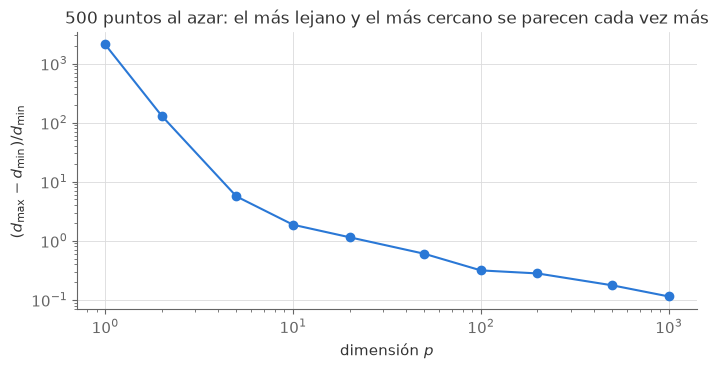

,1,2,5,10,20,50,100,200,500,1000
cociente,2102.43,130.41,5.63,1.87,1.15,0.6,0.31,0.28,0.18,0.11


In [4]:
plot_distance_concentration()

**Respuesta.** Con $p = 2$ el más lejano está ~100 veces más lejos; con $p = 1.000$, solo ~10 % más lejos. Con muchas columnas todos quedan casi a la misma distancia y "vecino" pierde sentido.

### 4.2 El escalado decide la geometría

📝 **Ejemplo resuelto:** distancia entre tres vendedores, antes y después de preparar los datos.

In [5]:
raw_distances(sellers, ids=(0, 1, 2))

,0-1,0-2,1-2
sin preparar,21445.77,1707.77,22900.19
log + escalado,4.76,6.08,3.65


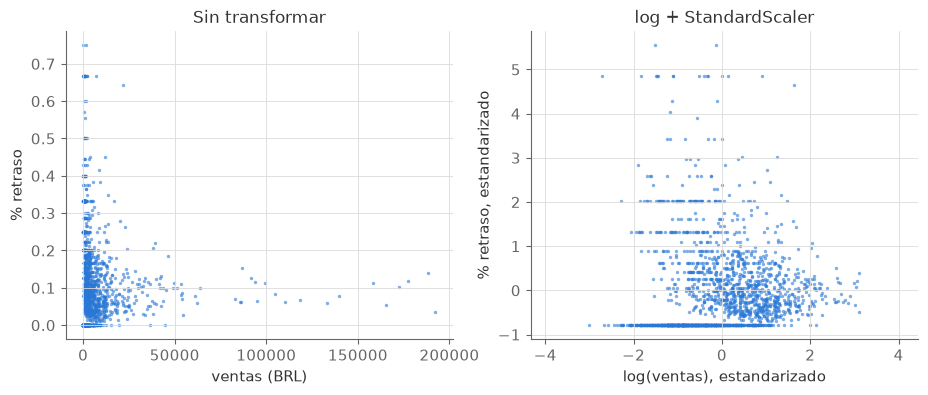

In [6]:
plot_scaling(sellers)

👀 **Qué mirar:** a la izquierda casi todos los vendedores están aplastados contra el eje vertical: ventas domina. A la derecha las dos variables pesan parecido.

💬 **Discuta:** si no escalamos, ¿qué "descubriría" un clustering?

**Respuesta.** Grupos por tamaño de ventas y nada más: las otras 7 columnas casi no cuentan en la distancia.

<a name="5"></a>
## 5. PCA

### 5.1 PCA a mano: el mini-mundo de las slides

📝 Seis puntos A–F. Centrar → covarianza → eigenvectores → proyectar.

media           = (4.33, 4.00)
covarianza      = [[9.07, 6.60], [6.60, 5.60]]
eigenvalores    = 14.16, 0.51
PC1             = (0.79, 0.61)
varianza en PC1 = 96.5%


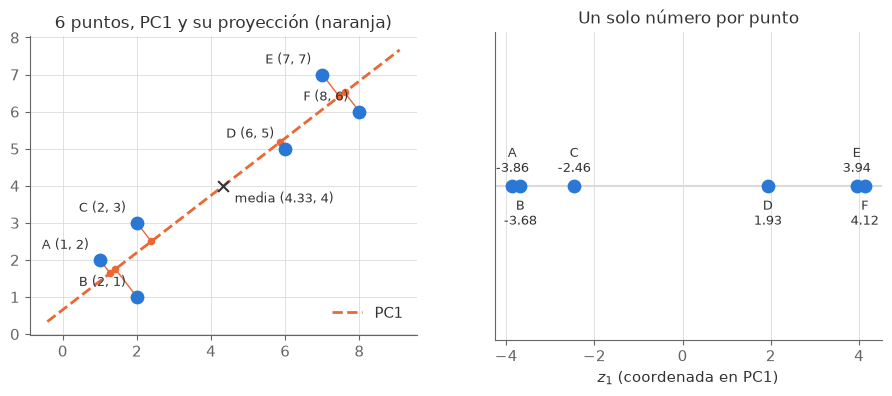

A   -3.86
B   -3.68
C   -2.46
D    1.93
E    3.94
F    4.12
Name: z1, dtype: float64

In [7]:
mini_pca()

**Lectura.** PC1 conserva el 96,5 % de la varianza: un solo número por punto separa {A, B, C} de {D, E, F}. Mañana estos mismos 6 puntos sirven para K-Means y DBSCAN.

### 5.2 ¿Cuántas componentes en Olist?

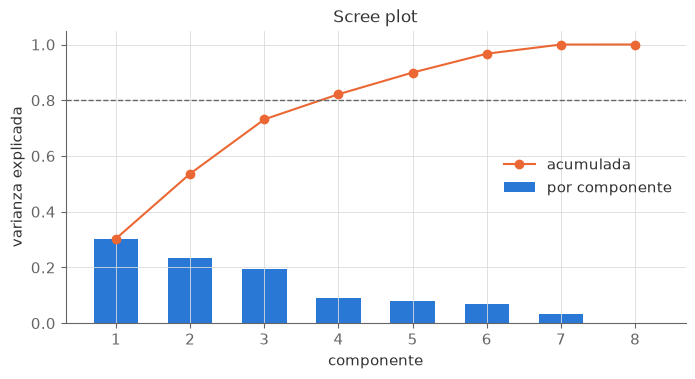

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
varianza,0.303,0.233,0.195,0.090,0.078,0.068,0.033,0.0
acumulada,0.303,0.536,0.731,0.822,0.899,0.967,1.000,1.0


In [8]:
pca = PCA().fit(X)
plot_scree(pca)

👀 **Qué mirar:** no hay un codo nítido. Con 4 componentes se llega a ~82 %. La última componente vale ~0: $\log(\text{ventas}) \approx \log(\text{órdenes}) + \log(\text{ticket})$, información repetida.

### 5.3 ¿Qué significa cada componente?

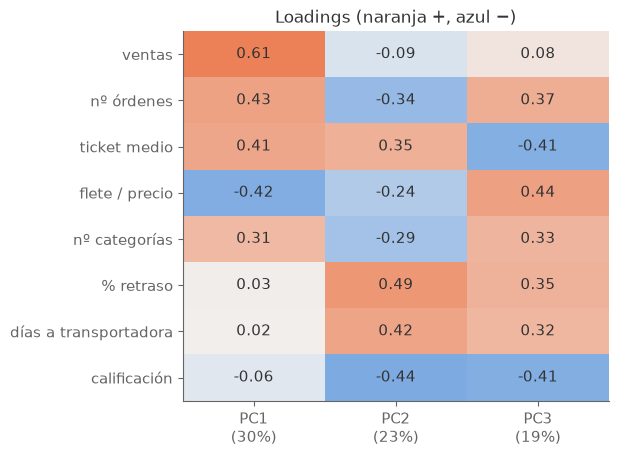

In [9]:
plot_loadings(pca)

👀 **Qué mirar:** cada columna es una componente; cada fila, cuánto pesa una variable.

- **PC1 ≈ tamaño del vendedor:** ventas, órdenes, ticket y categorías en naranja; flete relativo en azul.
- **PC2 ≈ mala experiencia de entrega:** % retraso y días a la transportadora en naranja; calificación en azul.

💬 **Discuta:** el signo de una componente es arbitrario. ¿Cambia la interpretación si PC2 sale con todos los signos al revés?

**Respuesta.** No. Cambia la dirección del eje, no lo que mide: "más mala entrega" pasaría a estar a la izquierda en lugar de a la derecha.

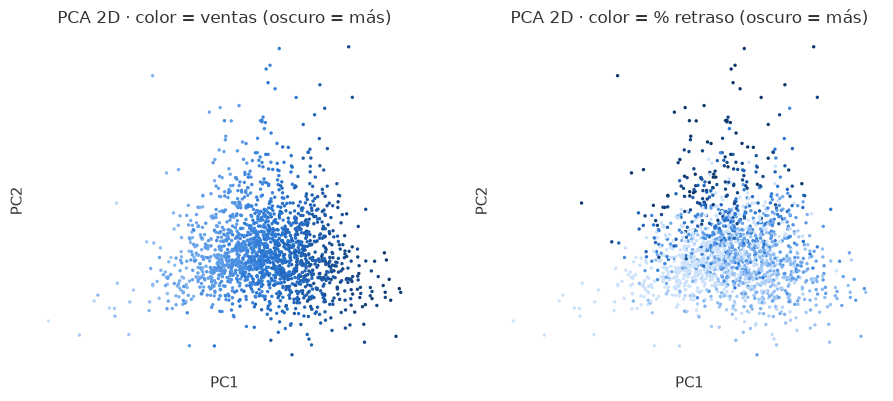

In [10]:
plot_pca_map(X, sellers)

👀 **Qué mirar:** el color de ventas cambia de izquierda a derecha (PC1); el de retraso, de abajo hacia arriba (PC2). Los ejes de PCA **sí** se pueden leer.

### 5.4 Reconstrucción

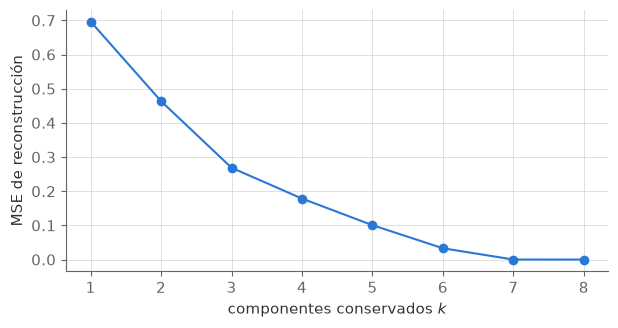

In [11]:
plot_reconstruction(X)

**Lectura.** Con $k = 4$ el error ya es bajo; con $k = 8$ es 0. Un vendedor que se reconstruye mal con pocas componentes no se parece a los demás: mañana eso será un score de anomalía.

<a name="6"></a>
## 6. t-SNE y UMAP

### 6.1 t-SNE: la perplexity cambia el mapa

🔮 **Prediga:** con perplexity 5 (mira 5 vecinos) frente a 100, ¿qué mapa tendrá más "islas"?

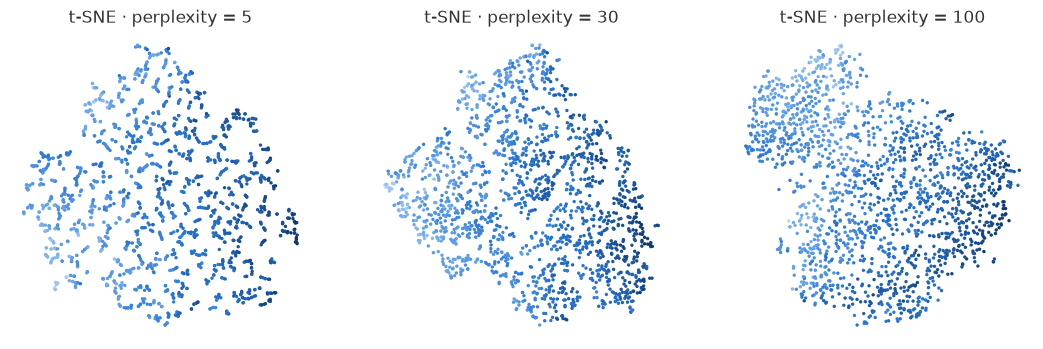

In [12]:
plot_tsne_perplexity(X, sellers)

**Respuesta.** Con perplexity baja aparecen muchas islas pequeñas; con alta, una nube más continua. **Los datos son los mismos.** El tamaño de las islas y la distancia entre ellas dependen del parámetro, no de los vendedores.

👀 **Qué mirar:** el gradiente de color (ventas) sí se repite en los tres mapas. Eso es lo que t-SNE conserva: quién es vecino de quién.

### 6.2 UMAP: `n_neighbors` y `min_dist`

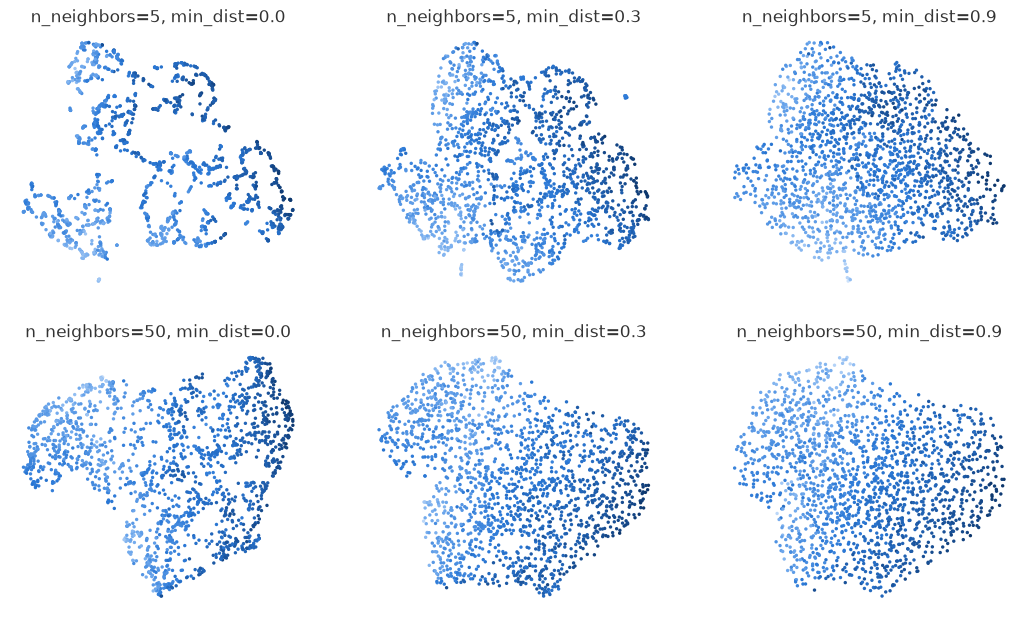

In [13]:
plot_umap_grid(X, sellers)

👀 **Qué mirar:**

- **fila de arriba (5 vecinos):** el mapa se rompe en hilos y fragmentos;
- **fila de abajo (50 vecinos):** forma más global y suave;
- **de izquierda a derecha (`min_dist`):** los puntos pasan de apretados a dispersos.

💬 **Discuta:** si alguien muestra el mapa de arriba a la izquierda como prueba de "muchos segmentos de vendedores", ¿qué le responde?

**Respuesta.** Que con otros parámetros razonables los "segmentos" desaparecen. Una conclusión que depende de un parámetro de visualización no es una conclusión sobre los datos.

<a name="7"></a>
## 7. Comparar los tres mapas

### 7.1 Mismos datos, tres métodos

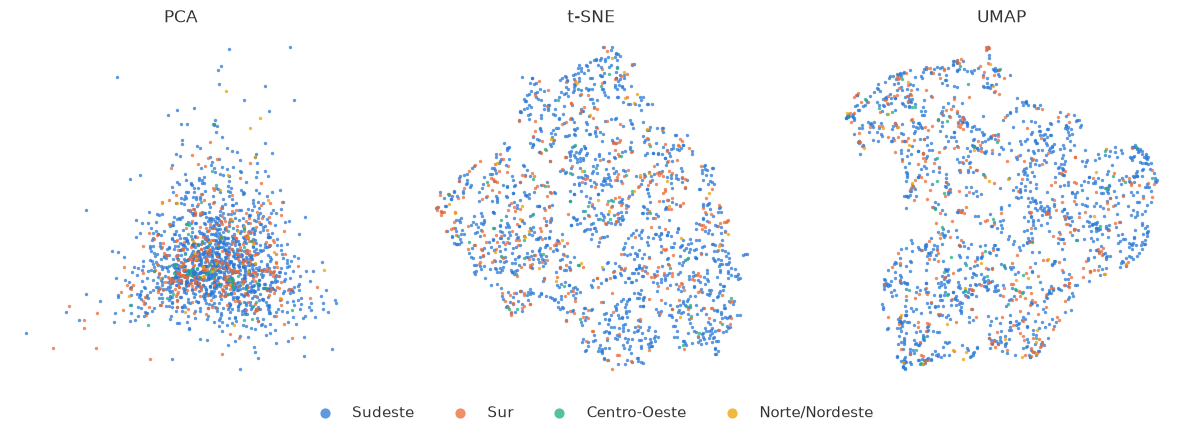

In [14]:
emb = embed_all(X)
plot_three_maps(emb, sellers, color="region")

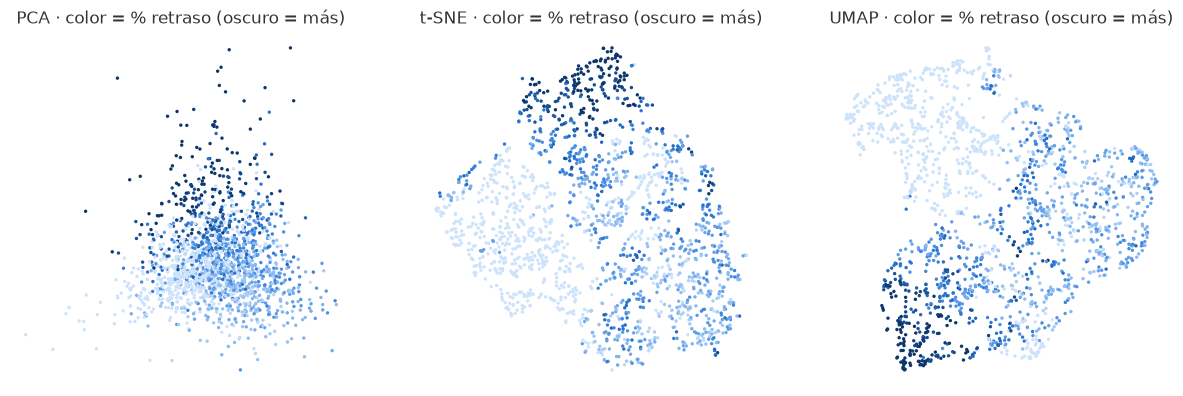

In [15]:
plot_three_maps(emb, sellers, color="late_rate")

👀 **Qué mirar:** coloreado por región **no** aparece ninguna estructura: la región no define vecindarios. Coloreado por % de retraso sí aparecen zonas. El mapa muestra lo que está en las variables que usamos.

### 7.2 Números en lugar de opiniones

In [16]:
embedding_scores(X, emb, sellers)

,trustworthiness,vecinos preservados,accuracy k-NN (retraso alto),segundos
PCA,0.836,0.109,0.664,0.001
t-SNE,0.983,0.446,0.844,1.753
UMAP,0.959,0.347,0.822,1.977
original 8D,1.000,1.000,0.908,0.000


**Lectura de la tabla:**

- **trustworthiness:** ¿los que se ven juntos en 2D eran vecinos de verdad? (1 = siempre). t-SNE y UMAP > 0,95; PCA ~0,84.
- **vecinos preservados:** de los 10 vecinos originales, ¿cuántos siguen siéndolo? Ni el mejor llega a la mitad: de 8 a 2 dimensiones se pierde mucho.
- **accuracy k-NN:** ¿el mapa conserva la información de retraso? El espacio original gana siempre; PCA 2D es el que más pierde.

### 7.3 ¿Es estable?

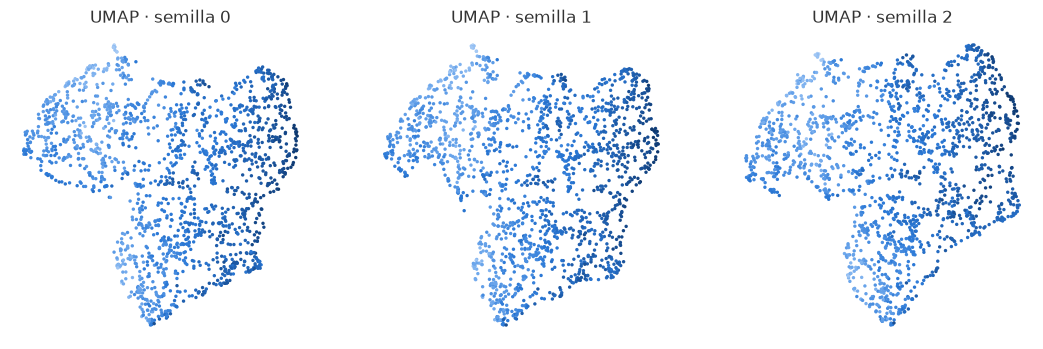

vecinos compartidos con la semilla 0: 60% en promedio


In [17]:
plot_seeds(X, sellers)

👀 **Qué mirar:** la forma del mapa cambia con la semilla; el gradiente de ventas se mantiene. Solo ~60 % de los vecinos coinciden entre semillas.

💬 **Discuta:** ¿qué partes de un mapa UMAP se pueden reportar y cuáles no?

**Respuesta.** Se puede reportar lo que se repite entre semillas y parámetros (gradientes, vecindarios). No la forma, el tamaño de las islas ni la distancia entre ellas.

<a name="8"></a>
## 8. Para seguir practicando

1. **Sin log:** quite `log1p` en `prepare` (use solo `StandardScaler`) y repita el scree plot y los loadings. ¿Qué componente cambia más?
2. **Menos variables:** use solo ventas, órdenes y ticket. ¿Qué muestran ahora los mapas?
3. **Clientes (taller):** adapte la consulta SQL a `customer_unique_id`. ¿Qué pasa con la frecuencia cuando casi todos compran una vez?
4. **UMAP a 10 dimensiones:** `run_umap(X, n_components=10, min_dist=0)` es la entrada típica de HDBSCAN. Lo usaremos en la sesión 6.

**La idea que debe quedar:** el escalado es parte del modelo; PCA conserva la varianza global y sus ejes se interpretan; t-SNE y UMAP conservan vecindarios, no distancias globales; ningún mapa sin métrica ni otras semillas.

---
**Curso:** Aprendizaje Automático — SI7009 · Universidad EAFIT · Sesión 5